In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [9]:
nspec=10
n=4096
k=100
dk=10
fbig=np.zeros(n*nspec//2+1,dtype='complex128')
fbig[k*nspec:k*nspec + dk*nspec]=np.random.randn(dk*nspec) + 1j * np.random.randn(dk*nspec)
x=np.fft.irfft(fbig)
m=len(x)

In [50]:
fbignew=np.zeros(n*nspec,dtype='complex128')
fbignew[:dk*nspec]=fbig[k*nspec:k*nspec + dk*nspec]
x2 = np.fft.ifft(fbignew)
fbignew2=np.fft.fft(x*np.exp(-2j*np.pi*k*np.arange(m)/n))

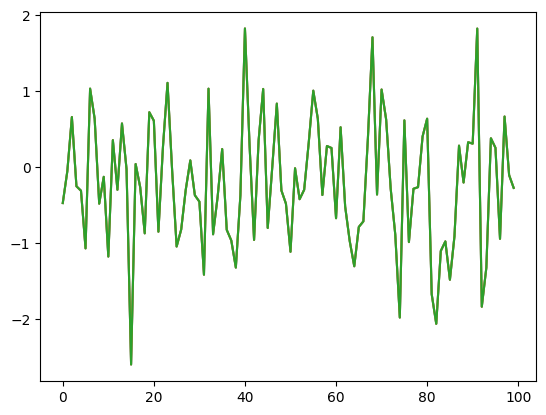

In [51]:
plt.plot(np.fft.fft(x)[k*nspec:k*nspec + dk*nspec])
plt.plot(np.fft.fft(x2)[:dk*nspec])
plt.plot(fbignew2[:dk*nspec])
# plt.plot(np.fft.fftshift(np.fft.fft(x*np.exp(2j*np.pi*k*np.arange(m)/n))))
# plt.plot(np.fft.fftshift(np.fft.fft(x*np.exp(-2j*np.pi*k*np.arange(m)/n))))
# plt.xlim(m//2-k*nspec-dk*nspec-1000,m//2+k*nspec+dk*nspec+1000)
# plt.xlim(m//2-2000,m//2+2000)

In [36]:
spec = np.fft.rfft(x.reshape(10,-1),axis=1)
print(spec.shape)

(10, 2049)


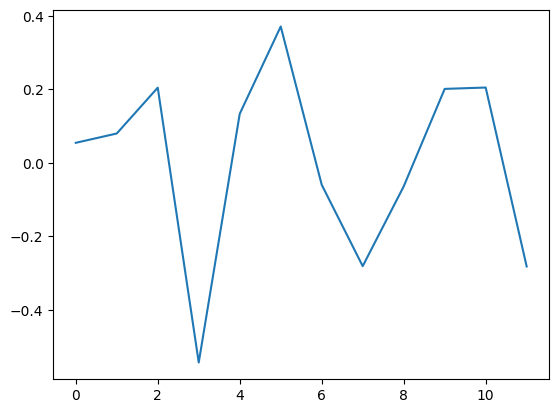

In [39]:
plt.plot(spec[5,k-2:k+dk])

In [57]:
dk

10

In [103]:


specnew = np.zeros((spec.shape[0],(spec.shape[1]-1)*2),dtype=spec.dtype)
extra=5
specnew[:,:dk+2*extra]=spec[:,k-extra:k+dk+extra]
x3 = np.ravel(np.fft.ifft(specnew,axis=1))

fbignew=np.zeros(n*nspec,dtype='complex128')
fbignew[:dk*nspec+2*extra*nspec]=fbig[(k-extra)*nspec:(k+dk+extra)*nspec]
x2 = np.fft.ifft(fbignew)

nlow = int(np.log2(dk+2*extra))+2
nlow=2**nlow
print("nlow",nlow)
specnew_low = np.zeros((spec.shape[0],nlow),dtype=spec.dtype)
specnew_low[:,:dk+2*extra]=spec[:,k-extra:k+dk+extra]
x3_low = np.ravel(np.fft.ifft(specnew_low,axis=1))

nlow 64


(0.0, 17000.0)

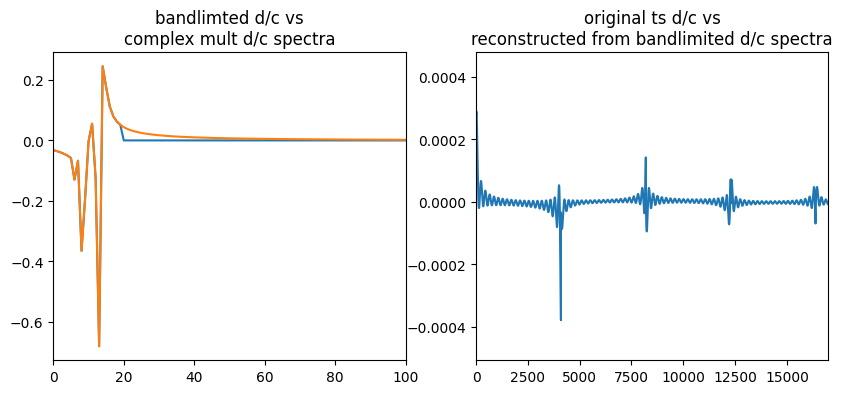

In [118]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.subplot(121)
plt.title("bandlimted d/c vs\ncomplex mult d/c spectra")
plt.plot(specnew[0,:])
xx=np.fft.irfft(spec[0,:])
plt.plot(np.fft.fft(xx*np.exp(-2j*np.pi*(k-extra)*np.arange(n)/n))) #manual vs automatic downconversion 
plt.xlim(0,100)

plt.subplot(122)
plt.title("original ts d/c vs\nreconstructed from bandlimited d/c spectra")
plt.plot(x3-x2)
plt.xlim(0,17000)

(0.0, 17000.0)

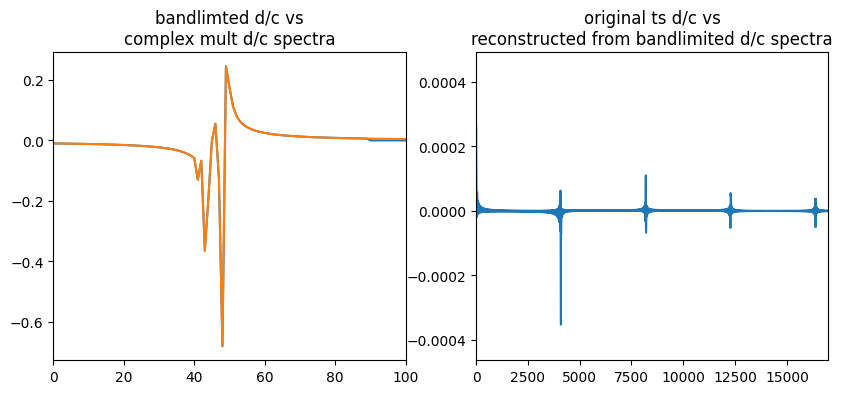

In [102]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.subplot(121)
plt.title("bandlimted d/c vs\ncomplex mult d/c spectra")
plt.plot(specnew[0,:])
xx=np.fft.irfft(spec[0,:])
plt.plot(np.fft.fft(xx*np.exp(-2j*np.pi*(k-extra)*np.arange(n)/n))) #manual vs automatic downconversion 
plt.xlim(0,100)

plt.subplot(122)
plt.title("original ts d/c vs\nreconstructed from bandlimited d/c spectra")
plt.plot(x3-x2)
plt.xlim(0,17000)

bigger the badlimit window, narrower the artefacts because conv kernel is sharper

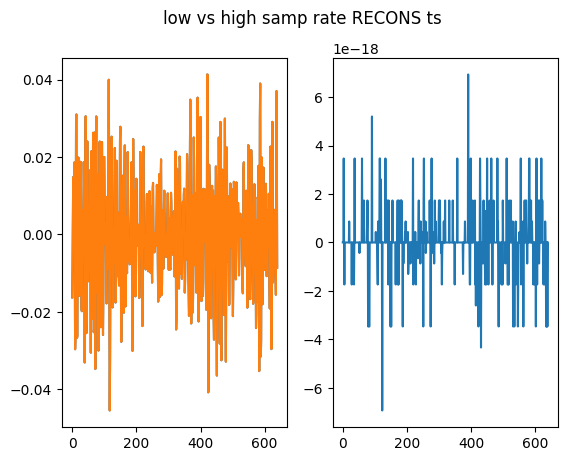

In [113]:

plt.suptitle("low vs high samp rate RECONS ts")
ratio=4096//nlow
plt.subplot(121)
plt.plot(x3[::ratio]*ratio)
plt.plot(x3_low)
plt.subplot(122)
plt.plot(x3[::ratio]*ratio-x3_low)

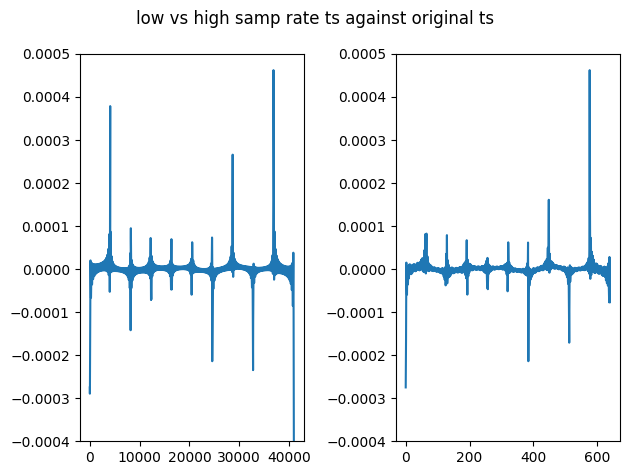

In [116]:

plt.suptitle("low vs high samp rate ts against original ts")
ratio=4096//nlow
plt.subplot(121)
plt.plot(x2-x3)
plt.ylim(-0.0004,0.0005)
plt.subplot(122)
plt.plot(x2[::ratio]-x3_low/ratio)
plt.ylim(-0.0004,0.0005)
plt.tight_layout()

In [49]:
len(x2)

20481